In [ ]:
import numpy as np
from ase.io.cube import read_cube_data

# Returns the 3D numpy array and an ASE Atoms object
data, atoms = read_cube_data("defc_afm1_up.cube")
print(atoms.get_positions())

cell = atoms.cell
shape = data.shape  # (nx, ny, nz)
spacing = cell / np.array(shape)[:, None]  # Step vectors for x, y, z

# Get the origin of the grid (in Angstrom) - defaults to (0,0,0) if not defined
# Accessing the origin attribute might differ depending on ASE version;
# the dictionary returned by read_cube() (called by read_cube_data) contains it.
# In case the origin is not available, default to the corner of the cell.
origin = np.zeros(3)

# Generate grid coordinates
grid_coords = []
for i in range(shape[0]):
    for j in range(shape[1]):
        for k in range(shape[2]):
            # Coordinate of the voxel corner
            coord = origin + i * spacing[0] + j * spacing[1] + k * spacing[2]
            weight = data[i, j, k]
            grid_coords.append([coord[0], coord[1], coord[2], weight])

# Convert to a NumPy array for easier handling
xyz_weight = np.array(grid_coords)
for i in range(3):
    print(np.min(xyz_weight[:,i]),np.max(xyz_weight[:,i]))
# Optionally, save to a file
np.savetxt('xyz_weights.txt', xyz_weight, header='x y z weight', comments='')
print(f"Successfully converted to (x, y, z, weight) format with {len(xyz_weight)} points.")


[[8.39081271 8.39081271 8.39081271]
 [4.19540636 4.19540636 4.19540636]
 [2.09770397 2.09770397 2.09770397]
 [6.29310927 6.29310927 6.29310927]]
Cell([[2.0637847710724535, 2.0637847710724535, 4.263303496654532], [2.0637847710724535, 4.263303496654532, 2.0637847710724535], [4.263303496654532, 2.0637847710724535, 2.0637847710724535]])
0.0 8.313179769921668
0.0 8.313179769921666
0.0 8.313179769921666
Successfully converted to (x, y, z, weight) format with 1259712 points.


In [20]:
x= xyz_weight[:,0]
y= xyz_weight[:,1]
z= xyz_weight[:,2]
print(np.diff(np.unique(x)))


[0.01910912 0.01910912 0.0012568  ... 0.0012568  0.01910912 0.01910912]


1
[0.         0.01910912 0.03821824 ... 8.27496153 8.29407065 8.31317977]


ValueError: x and y arrays must have a length of at least 3

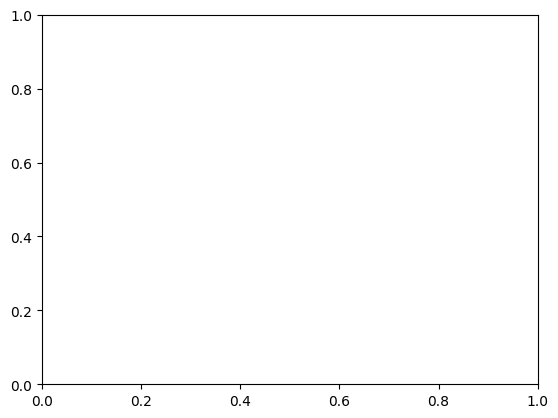

In [6]:
from matplotlib import pyplot as plt

x = xyz_weight[:,0]
y = xyz_weight[:,1]
z = xyz_weight[:,2]
w = xyz_weight[:,3]
z_slice=z[0]
print(np.sum(z==z[0]))
print(np.unique(z))
plt.tricontourf(x[z==z_slice],y[z==z_slice],w[z==z_slice],np.linspace(-0.05,0.05))
plt.colorbar()

Grid size: 60x60x75
Atom position: [3.17410228 3.17410228 2.06394458]
Grid indices: ix=59, iy=59, iz=37


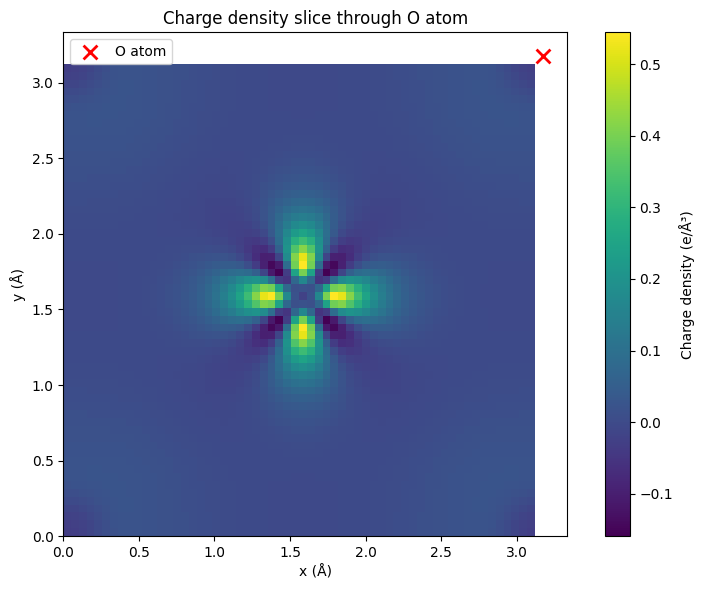

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io.cube import read_cube_data

data, atoms = read_cube_data("defc_afm2.cube")

# Choose atom
atom_idx =2
atom_pos = atoms.positions[atom_idx]

# Get grid information
nx, ny, nz = data.shape
cell = atoms.cell
dx, dy, dz = cell[0,0]/nx, cell[1,1]/ny, cell[2,2]/nz

# Find grid indices for atom position
ix = int(round(atom_pos[0]/dx))
iy = int(round(atom_pos[1]/dy))
iz = int(round(atom_pos[2]/dz))

# Ensure indices are within bounds
ix = max(0, min(ix, nx-1))
iy = max(0, min(iy, ny-1))
iz = max(0, min(iz, nz-1))

print(f"Grid size: {nx}x{ny}x{nz}")
print(f"Atom position: {atom_pos}")
print(f"Grid indices: ix={ix}, iy={iy}, iz={iz}")

# Choose which plane to display
plane = 'xy'  # Options: 'xy', 'xz', 'yz'

if plane == 'xy':
    # XY plane at the atom's z position
    slice_data = data[:, :, iz]
    x_coords = np.arange(nx) * dx
    y_coords = np.arange(ny) * dy
    x_label, y_label = 'x (Å)', 'y (Å)'
    atom_x, atom_y = atom_pos[0], atom_pos[1]
    extent = [x_coords[0], x_coords[-1], y_coords[0], y_coords[-1]]
    
elif plane == 'xz':
    # XZ plane at the atom's y position
    slice_data = data[:, iy, :]
    x_coords = np.arange(nx) * dx
    z_coords = np.arange(nz) * dz
    x_label, y_label = 'x (Å)', 'z (Å)'
    atom_x, atom_y = atom_pos[0], atom_pos[2]
    extent = [x_coords[0], x_coords[-1], z_coords[0], z_coords[-1]]
    
else:  # 'yz'
    # YZ plane at the atom's x position
    slice_data = data[ix, :, :]
    y_coords = np.arange(ny) * dy
    z_coords = np.arange(nz) * dz
    x_label, y_label = 'y (Å)', 'z (Å)'
    atom_x, atom_y = atom_pos[1], atom_pos[2]
    extent = [y_coords[0], y_coords[-1], z_coords[0], z_coords[-1]]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(slice_data.T, origin='lower', cmap='viridis',
               extent=extent, aspect='auto')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Charge density (e/Å³)')

# Mark the atom position
ax.scatter(atom_x, atom_y, color='red', s=100, marker='x', 
           label=f'{atoms.symbols[atom_idx]} atom', linewidth=2)

ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.set_title(f'Charge density slice through {atoms.symbols[atom_idx]} atom')
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'cube_tools' is not defined

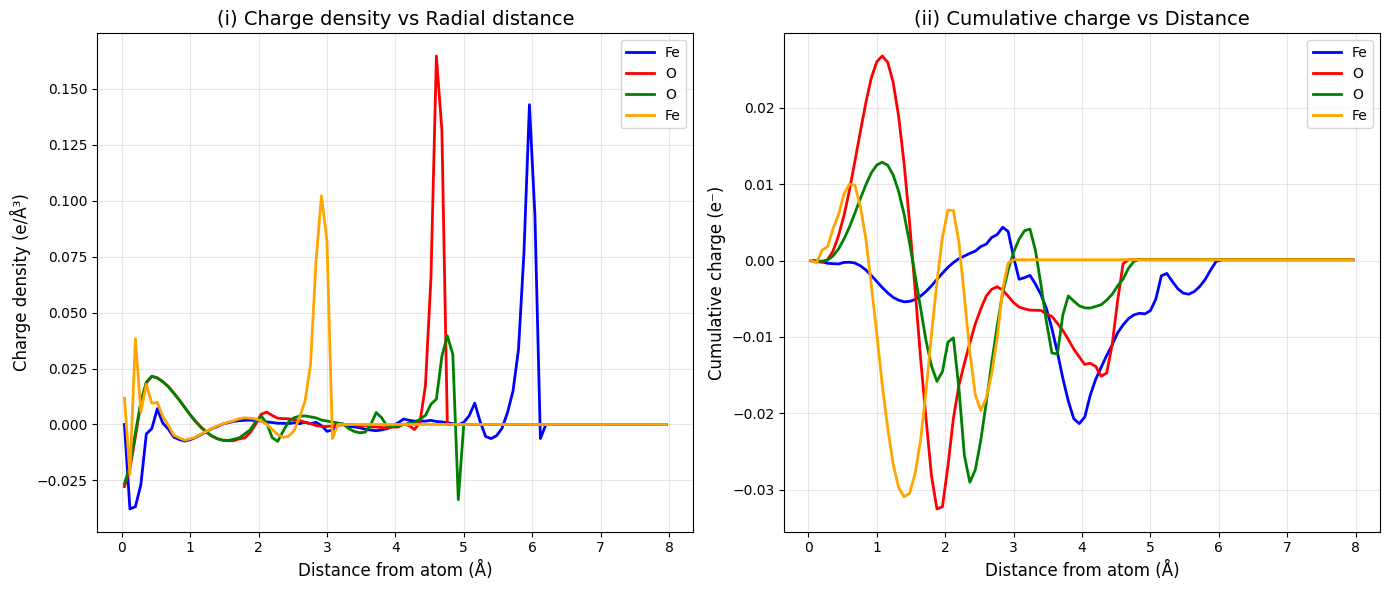

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io.cube import read_cube_data

def compute_radial_charge_density(data, atoms, atom_idx, r_max=None, n_bins=100):
    # Same function as above
    atom_pos = atoms.positions[atom_idx]
    nx, ny, nz = data.shape
    cell = atoms.cell
    dx, dy, dz = cell[0,0]/nx, cell[1,1]/ny, cell[2,2]/nz
    
    x = (np.arange(nx) - atom_pos[0]/dx) * dx
    y = (np.arange(ny) - atom_pos[1]/dy) * dy
    z = (np.arange(nz) - atom_pos[2]/dz) * dz
    
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    r = np.sqrt(X**2 + Y**2 + Z**2)
    
    if r_max is None:
        r_max = min(cell[0,0], cell[1,1], cell[2,2]) / 2
    
    r_flat = r.flatten()
    data_flat = data.flatten()
    
    bins = np.linspace(0, r_max, n_bins + 1)
    r_centers = (bins[:-1] + bins[1:]) / 2
    
    radial_density = np.zeros(n_bins)
    shell_charge = np.zeros(n_bins)
    
    for i in range(n_bins):
        mask = (r_flat >= bins[i]) & (r_flat < bins[i+1])
        if np.any(mask):
            radial_density[i] = np.mean(data_flat[mask])
            shell_charge[i] = np.sum(data_flat[mask]) * dx * dy * dz
    
    cumulative_charge = np.cumsum(shell_charge)
    
    return r_centers, radial_density, cumulative_charge

# Read data
data, atoms = read_cube_data("defc_afm2.cube")

# Analyze multiple atoms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['blue', 'red', 'green', 'orange', 'purple']
atom_indices = [0, 1, 2, 3, 4]

for idx, color in zip(atom_indices, colors):
    if idx >= len(atoms):
        break
    
    r, density, cum_charge = compute_radial_charge_density(
        data, atoms, idx, r_max=8.0, n_bins=100
    )
    
    ax1.plot(r, density, color=color, linewidth=2, 
             label=f'{atoms.symbols[idx]}')
    ax2.plot(r, cum_charge, color=color, linewidth=2,
             label=f'{atoms.symbols[idx]}')

# Format plots
ax1.set_xlabel('Distance from atom (Å)', fontsize=12)
ax1.set_ylabel('Charge density (e/Å³)', fontsize=12)
ax1.set_title('(i) Charge density vs Radial distance', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.set_xlabel('Distance from atom (Å)', fontsize=12)
ax2.set_ylabel('Cumulative charge (e⁻)', fontsize=12)
ax2.set_title('(ii) Cumulative charge vs Distance', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()